## Human Development Index

The Human Development Index (HDI) is an index used by the UN to measure the progression of human development around the world. Two of the key aspects they look at are:

1. Life expectancy
2. Gross National Income per capita (adjusted for the price level of the country).

We're going to take a look at some of the data for this and perform some analyses using some more advanced techniques from the `pandas` and `numpy` libraries.

We'll begin by loading in the libraries, and taking a look at the life expectancy data.

KATE expects your code to define variables with specific names that correspond to certain things we are interested in.

KATE will run your notebook from top to bottom and check the latest value of those variables, so make sure you don't overwrite them.

* Remember to uncomment the line assigning the variable to your answer and don't change the variable or function names.
* Use copies of the original or previous DataFrames to make sure you do not overwrite them by mistake.

You will find instructions below about how to define each variable.

Once you're happy with your code, upload your notebook to KATE to check your feedback.

In [7]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

life_expectancy  = pd.read_csv('data/life-expectancy.csv')

life_expectancy.head(5)

,Entity,Code,Year,Life expectancy
0,Afghanistan,AFG,1950,27.638
1,Afghanistan,AFG,1951,27.878
2,Afghanistan,AFG,1952,28.361
3,Afghanistan,AFG,1953,28.852
4,Afghanistan,AFG,1954,29.350


**1. Create a pivot table so that there is one column per year, and only one row per country, with the values in each cell being the life expectancy. The rows should be ordered alphabetically.**

Store the answer in a variable called `pivot`.

In [8]:
# Add your code below
pivot = life_expectancy.pivot(index="Entity", columns="Year", values="Life expectancy")
pivot.head()


Year,1543,1548,1553,1558,1563,1568,1573,1578,1583,1588,...,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019
Entity,,,,,,,,,,,,,,,,,,,,,
Afghanistan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,61.028,61.553,62.054,62.525,62.966,63.377,63.763,64.130,64.486,64.833
Africa,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,58.576,59.263,59.914,60.527,61.093,61.607,62.064,62.472,62.839,63.170
Albania,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,76.562,76.914,77.252,77.554,77.813,78.025,78.194,78.333,78.458,78.573
Algeria,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,74.938,75.199,75.436,75.661,75.878,76.090,76.298,76.499,76.693,76.880
American Samoa,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,73.126,73.295,73.419,73.506,73.559,73.588,73.609,73.636,73.679,73.745


**2. How many years contain NaNs and how many do not?**

On the pivot table, check which entries contain NaNs using `.isnull()`. You can then use `.any()` to get a single boolean value for a whole column (indicating whether *any* value in that column is False). Use `.value_counts()` to get counts for True and False. Assign the output of `.value_counts()` to a variable called `num_nans`.


In [9]:
# Add your code below
num_nans = pivot.isnull().any().value_counts()
num_nans.head()

True     241
False     70
Name: count, dtype: int64

**3. Using similar logic, return a boolean which indicates whether any row in 2019 contains a NaN.**

Store the result in a variable named `nan_in_2019`.

In [10]:
# Add your code below
nan_in_2019 = pivot[2019].isnull().any()
nan_in_2019


np.False_

**4. Using `.groupby`, show the `mean` life expectancy throughout the world for each year.**

Store the resulting dataframe in a variable named `year_vs_life_exp`.

In [12]:
# Add your code below
year_vs_life_exp = life_expectancy.groupby('Year')['Life expectancy'].mean()
year_vs_life_exp.head()

Year
1543    33.939999
1548    38.820000
1553    39.590000
1558    22.379999
1563    36.660000
Name: Life expectancy, dtype: float64

Once you have implemented `year_vs_life_exp`, we can uncomment the cell below and visualise the trend for this data:

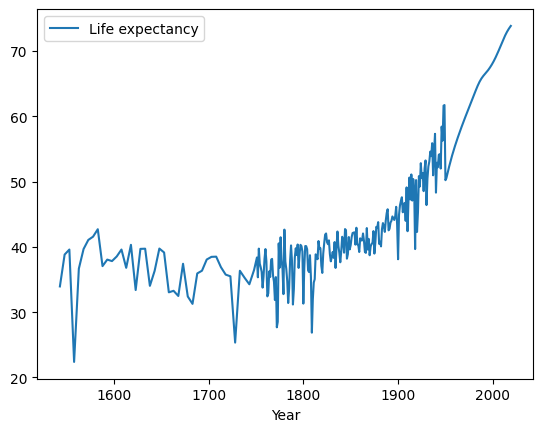

In [13]:
year_vs_life_exp.reset_index().plot('Year','Life expectancy');

**5. `melt` the dataframe `pivot` into a table with an index and three columns: Entity, Year, Life expectancy. Assign this to a variable called `melted_pivot`**


*Hint: you may need to use `.reset_index()` to make 'Entity' indexable again.*

In [14]:
# Add your code below
melted_pivot = pivot.reset_index().melt(
    id_vars='Entity',
    var_name='Year',
    value_name='Life expectancy'
)
melted_pivot

,Entity,Year,Life expectancy
0,Afghanistan,1543,NaN
1,Africa,1543,NaN
2,Albania,1543,NaN
3,Algeria,1543,NaN
4,American Samoa,1543,NaN
...,...,...,...
75568,Western Sahara,2019,70.263
75569,World,2019,72.584
75570,Yemen,2019,66.125
75571,Zambia,2019,63.886


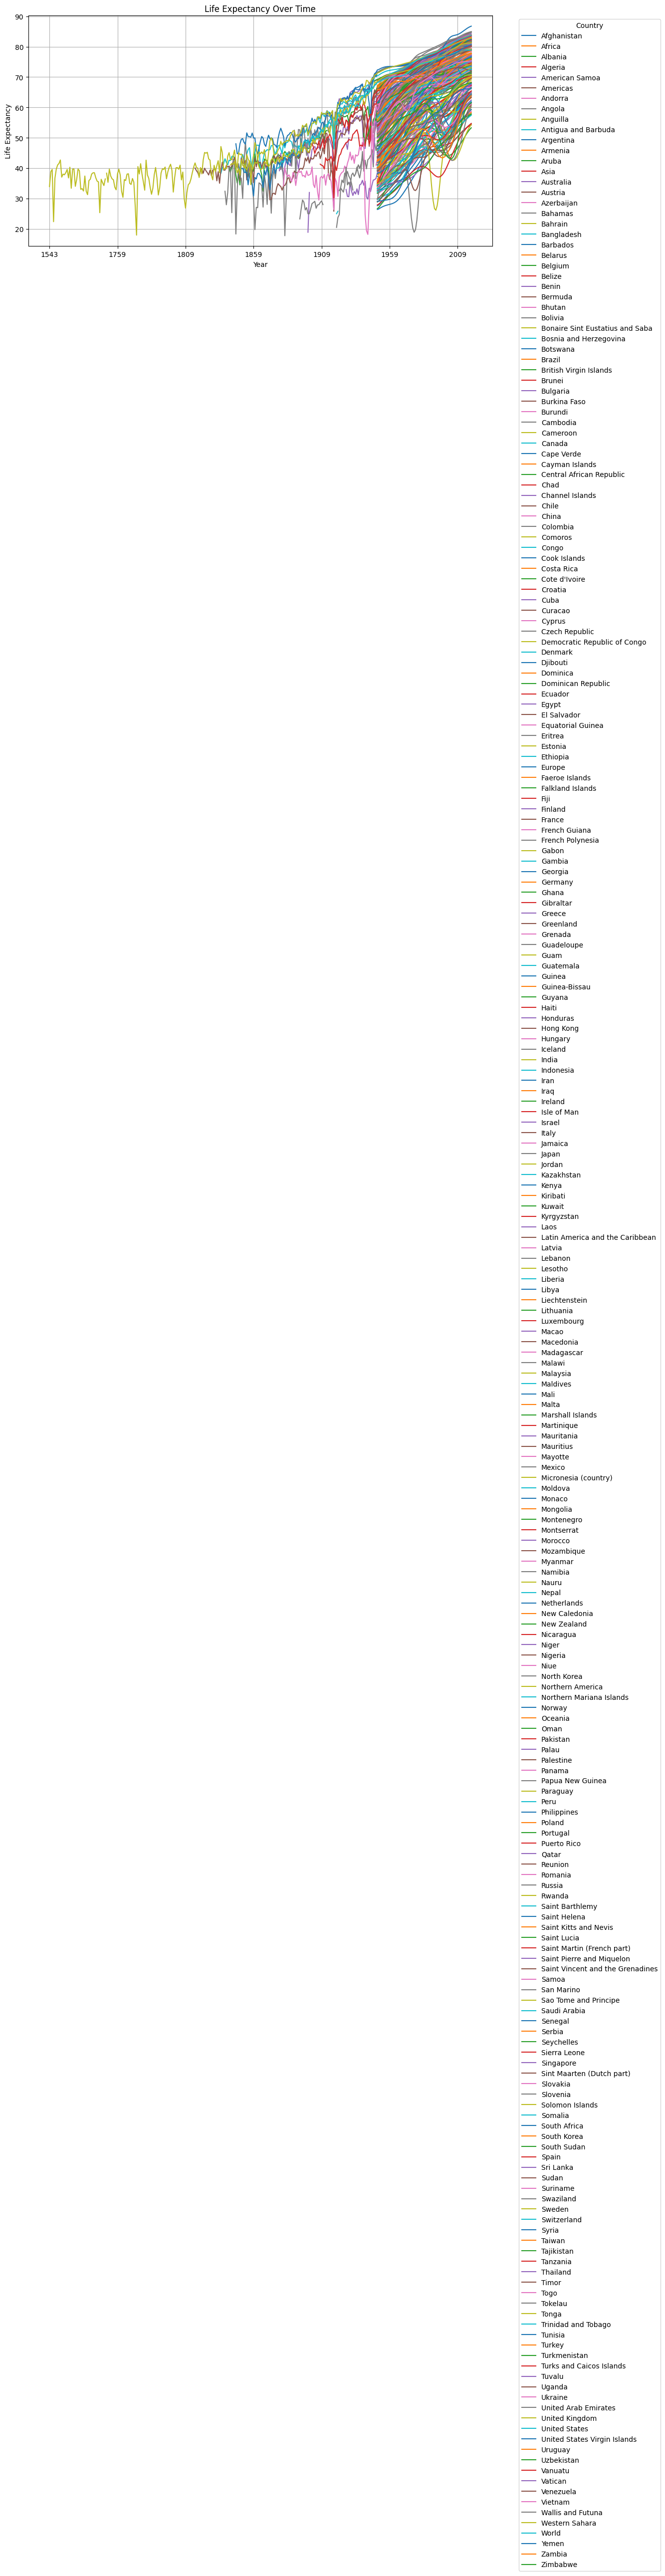

In [15]:
import matplotlib.pyplot as plt

pivoted_plot = melted_pivot.pivot(index='Year', columns='Entity', values='Life expectancy')

pivoted_plot.plot(figsize=(12,6), title='Life Expectancy Over Time')

plt.xlabel('Year')
plt.ylabel('Life Expectancy')
plt.grid(True)
plt.legend(title='Country', bbox_to_anchor=(1.05, 1))  # optional: move legend outside
plt.show()

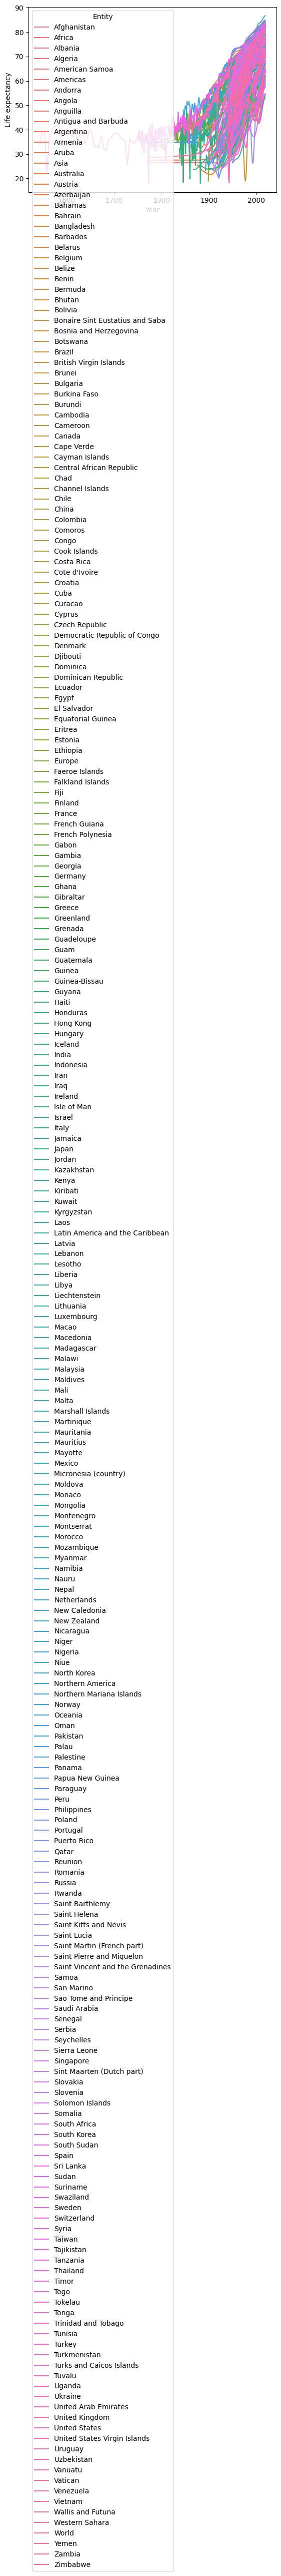

In [17]:
import seaborn as sns

sns.lineplot(
    data=melted_pivot,
    x='Year',
    y='Life expectancy',
    hue='Entity'  # separate line for each country
)
plt.show()

## Gross National Income per capita

Let's take a look at the GNI data:

In [18]:
gni_per_capita = pd.read_csv('data/gross-national-income-per-capita.csv')



The problem is that it doesn't actually tell us population size. There's another dataframe with this data in it:

In [19]:
hihd = pd.read_csv('data/hihd-without-gdp-vs-gdp-per-capita.csv')

**6. Add a 'Population' column to the `gni_per_capita` dataframe**

As a first step, create a new column called 'Population', in the `gni_per_capita` dataframe and -- for now -- fill it with `np.nan`s.

In [20]:
# Add your code below
gni_per_capita['Population'] = np.nan
gni_per_capita.head()

,Entity,Code,Year,"GNI per capita, PPP (constant 2011 international $)",Population
0,Afghanistan,AFG,2002,1061.366599,NaN
1,Afghanistan,AFG,2003,1097.601465,NaN
2,Afghanistan,AFG,2004,1063.819645,NaN
3,Afghanistan,AFG,2005,1138.095434,NaN
4,Afghanistan,AFG,2006,1167.882120,NaN


Now, make a list called `popns` which has the correct population value for each row of the dataframe.

To achieve this, you will need to use information from both the `hihd` and the `gni_per_capita` dataframes:
  1. First, get a unique list of countries from `gni_per_capita` (specifically, the `Entity` column). 
  2. Iterate through this list and, on each iteration:
     - Retrieve the `Year` column from `gni_per_capita` for that country. Assign it to a variable called `years`
     - Get the rows containing the total population from the `hihd` dataframe for that country and those `years` (the `Total population (Gapminder, HYDE & UN)` column)
     - If the number of rows for the two above dataframe slices are equal, add the population values to the `popns` list
     - Otherwise, add as many `np.nan`s to the `popns` list as there are items in `years`
     
The idea here is to add population data where it matches the country and year. However, if we find a mismatch in the number of years of data for any given country, we discard all population data from `hihd` and just add null values (`np.nan`) for all the years of data we have for that country in `gni_per_capita`.

In [21]:
# Add your code here
popns = []
countries = gni_per_capita['Entity'].unique()

for country in countries:
    years = gni_per_capita.loc[gni_per_capita['Entity'] == country, 'Year']

    hihd_mask = (
        (hihd['Entity'] == country) &
        (hihd['Year'].isin(years))
    )
    pop_values = hihd.loc[hihd_mask, 'Total population (Gapminder, HYDE & UN)']

    if len(pop_values) == len(years):
        popns.extend(pop_values.values)
    else:
        popns.extend([np.nan] * len(years))

gni_per_capita['Population'] = popns

Now we should be able to fill this `Population` column in properly and inspect the dataframe:

In [22]:
gni_per_capita.head()

,Entity,Code,Year,"GNI per capita, PPP (constant 2011 international $)",Population
0,Afghanistan,AFG,2002,1061.366599,22601000.0
1,Afghanistan,AFG,2003,1097.601465,23681000.0
2,Afghanistan,AFG,2004,1063.819645,24727000.0
3,Afghanistan,AFG,2005,1138.095434,25654000.0
4,Afghanistan,AFG,2006,1167.882120,26433000.0


**7. Let's take a closer look at the year 2011 (since that's where our GNI per capita data comes from).**

 - Use `gni_per_capita.loc[...]` to sample only the rows from `gni_per_capita` where the `Year` equals 2011. It may be useful to create a mask. Assign this output to a variable called `df`

 - Since we actually have quite a few countries here, visualising all of them at the same time might look a bit cluttered. To filter down the contents of `df`, use the Python slice operator (`::`) with a step-size of 10 to reduce the number of rows in `df`.

 - Next, let's do some cleaning up of our dataframe: use the `.dropna()` and `.reset_index(drop=True)` functions to remove unwanted data and wipe the `df` index (remember to reassign your `df` variable to the results of these functions)

 - Note that you should make use of the `.copy()` method when defining `df`. The sample code below provides some guidance as to how this should look.

In [23]:
# Add your code here
mask = gni_per_capita['Year'] == 2011
df = gni_per_capita.loc[mask].copy()
df = df[::10]                          # every 10th row
df = df.dropna().reset_index(drop=True)



**8. Create a new DataFrame as a `.copy()` of `df` and call it `df_life_expectancy`. Add a new column 'Life expectancy' to `df_life_expectancy`, taken from the `life_expectancy` dataframe (from the year 2011).**

In [24]:
# Add your code here...
df_life_expectancy = df.copy()

le_2011 = life_expectancy[life_expectancy['Year'] == 2011][['Entity', 'Life expectancy']]
df_life_expectancy = df_life_expectancy.merge(le_2011, on='Entity', how='left')


Now we're going to use the function `plot_blobs` below to visualise the data:

In [25]:
# df: the DataFrame to plot
# s: a list of sizes for each blob
def plot_blobs(df, s):
    fig, ax = plt.subplots(figsize=(10, 5))
    gni = 'GNI per capita, PPP (constant 2011 international $)'
    df.plot('Life expectancy', gni, kind='scatter', ax=ax, alpha=0.5, s=s)
    for i, (k, v) in enumerate(df.sort_values('Life expectancy').iterrows()):
        if i % 2 == 0:
            ax.annotate(v['Entity'], (v['Life expectancy'], v[gni]))

**9. Scale each blob by their population.**

Create a list `s` which contains the sizes. Assume `100` is the size for the smallest population, and then scale the others by their ratio to the smallest. For example, if country A is the smallest then their size should be 100. If country B has double the population, their size should be 200.

Don't worry about overlapping text. If you're curious, you can check out the [adjustText](https://github.com/Phlya/adjustText) library for matplotlib - but since this is unrelated to pandas and numpy we'll omit it for now.

In [26]:
# Add your code below
min_pop = df_life_expectancy['Population'].min()
s = (df_life_expectancy['Population'] / min_pop * 100).tolist()

The following call should now produced a nicely scaled plot:

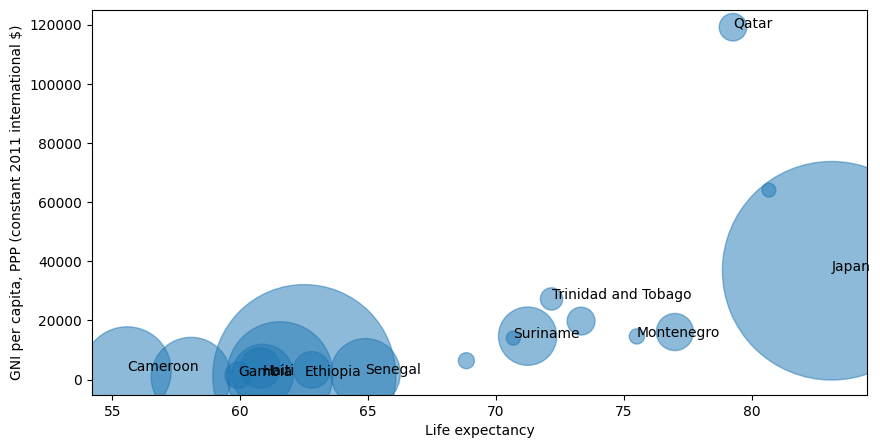

In [27]:
plot_blobs(df_life_expectancy, s);

**10. Use `qcut` to create three population size groups ["Small","Medium","Large"].**

First create a new Dataframe called `df_category` as a `.copy()` of `df_life_expectancy`. Then assign the output of `qcut` to a new column in `df_category` called `Popn. category`.

In [28]:
# Add your code below
df_category = df_life_expectancy.copy()
df_category['Popn. category'] = pd.qcut(
    df_category['Population'],
    q=3,
    labels=["Small", "Medium", "Large"]
)


**11. Create a new DataFrame from `df_category` called `df_multi_index` so it has a row MultiIndex over each category.**  

You should start by creating `df_multi_index` as a `.copy()` of `df_category`

*Hint: `pivot` creates a column MultiIndex. `stack` converts a column MultiIndex into a row MultiIndex.*


In [29]:
# Add your code below
df_multi_index = df_category.copy()
df_multi_index = df_multi_index.set_index(['Popn. category', 'Entity']).sort_index()
df_multi_index


Code  Year  \
Popn. category Entity                           
Small          Bhutan               BTN  2011   
               Gambia               GMB  2011   
               Luxembourg           LUX  2011   
               Montenegro           MNE  2011   
               Qatar                QAT  2011   
               Suriname             SUR  2011   
               Trinidad and Tobago  TTO  2011   
Medium         Azerbaijan           AZE  2011   
               Congo                COG  2011   
               Haiti                HTI  2011   
               Latvia               LVA  2011   
               Mauritania           MRT  2011   
               Panama               PAN  2011   
Large          Afghanistan          AFG  2011   
               Cameroon             CMR  2011   
               Ethiopia             ETH  2011   
               Japan                JPN  2011   
               Niger                NER  2011   
               Senegal              SEN  2011   

                                    GNI per capita, PPP (constant 2011 international $)  \
Popn. category Entity                                                                     
Small          Bhutan                                                     6379.980282     
               Gambia                                                     1470.663871     
               Luxembourg                                                64050.617590     
               Montenegro                                                14588.920303     
               Qatar                                                    119118.399222     
               Suriname                                                  14005.556862     
               Trinidad and Tobago                                       27264.398094     
Medium         Azerbaijan                                                14676.419759     
               Congo                                                      3872.239455     
               Haiti                                                      1570.134675     
               Latvia                                                    19767.983301     
               Mauritania                                                 3270.698598     
               Panama                                                    16080.761372     
Large          Afghanistan                                                1679.272073     
               Cameroon                                                   2938.365391     
               Ethiopia                                                   1160.254480     
               Japan                                                     36788.077186     
               Niger                                                       795.389333     
               Senegal                                                    2115.919959     

                                     Population  Life expectancy  
Popn. category Entity                                             
Small          Bhutan                  693000.0           68.840  
               Gambia                 1848000.0           59.917  
               Luxembourg              519000.0           80.664  
               Montenegro              625000.0           75.505  
               Qatar                  2036000.0           79.260  
               Suriname                535000.0           70.676  
               Trinidad and Tobago    1336000.0           72.170  
Medium         Azerbaijan             9146000.0           71.234  
               Congo                  4395000.0           60.785  
               Haiti                 10100000.0           60.879  
               Latvia                 2094000.0           73.323  
               Mauritania             3599000.0           62.799  
               Panama                 3706000.0           76.989  
Large          Afghanistan           30117000.0           61.553  
               Camero

**12. Use `.loc` to get a sub-dataframe of countries in the Medium category.**

Assign it to a variable called `df_medium`

In [30]:
# Add your code here
df_medium = df_multi_index.loc['Medium']